In [1]:
import torch
import torch.nn as nn
import torchvision.models as models
import os
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision.transforms import InterpolationMode
import torchvision.transforms.functional as TF
import time
from tqdm import tqdm
import torch.nn.functional as F



In [2]:
# import os

# KAGGLE_INPUT = "/kaggle/input"

# for root, dirs, files in os.walk(KAGGLE_INPUT):
#     level = root.replace(KAGGLE_INPUT, '').count(os.sep)
#     indent = ' ' * 4 * level
#     print(f"{indent}{os.path.basename(root)}/")
    
#     subindent = ' ' * 4 * (level + 1)
#     for f in files[:5]:   # show first 5 files only
#         print(f"{subindent}{f}")

In [3]:
scaler = torch.amp.GradScaler('cuda')

device = "cuda" if torch.cuda.is_available() else "cpu"


SHOW_PROGRESS = False
num_epochs =70
num_epochs_s2 = 45



print(f"Device        : {device}")
print(f"Epochs        : {num_epochs}")


Device        : cuda
Epochs        : 70


In [4]:
# ==========================================
# DATASET PATH CONFIG
# ==========================================

DATASET = "LIM-CD"   # "LEVIR-CD" or "LIM-CD"

if DATASET == "LEVIR-CD":
    ROOT = "/kaggle/input/datasets/mdrifaturrahman33/levir-cd/LEVIR CD"
    DIRMAP  = {"A": "A", "B": "B", "label": "label"}
    TILESIZE = 256     # LEVIR native=1024, must patch to 256
    STRIDE   = 128       # ← was 256, now overlapping patches (4× more data)
    BATCH_SIZE = 8
    POSWEIGHT    = 2.5
    MIN_CHANGE   = 10
    FOCAL_ALPHA  = 0.25
    DROPOUT_P   = 0.0 

elif DATASET == "LIM-CD":
    ROOT = "/kaggle/input/datasets/ravat1920/lim-cd/lim-cd"
    DIRMAP  = {"A": "t1", "B": "t2", "label": "label"}
    TILESIZE = 512     # LIM-CD native=512, no patching needed
    STRIDE   = 512
    BATCH_SIZE = 4     # halved due to 4× larger input
    POSWEIGHT    = 1.5    # less imbalanced dataset
    MIN_CHANGE   = 40     # scaled: same 0.015% threshold at 512×512
    FOCAL_ALPHA  = 0.5    # balanced when imbalance is lower
    DROPOUT_P   = 0.2

print("Dataset :", DATASET)        # ← was USE_DATASET (NameError)
print("Root    :", ROOT)
print("Mapping :", DIRMAP)         # ← was DIRMAP (NameError)
print(f"TileSize : {TILESIZE}  Stride : {STRIDE}  Batch : {BATCH_SIZE}")
print(f"PosWeight: {POSWEIGHT}  MinChange: {MIN_CHANGE}  FocalAlpha: {FOCAL_ALPHA}")

Dataset : LIM-CD
Root    : /kaggle/input/datasets/ravat1920/lim-cd/lim-cd
Mapping : {'A': 't1', 'B': 't2', 'label': 'label'}
TileSize : 512  Stride : 512  Batch : 4
PosWeight: 1.5  MinChange: 40  FocalAlpha: 0.5


In [5]:
class PatchedChangeDataset(Dataset):
    def __init__(self, root_dir, augment=False,
                 tile_size=TILESIZE, stride=STRIDE,
                 min_change_pixels=10,
                 neg_ratio=1.5):          # None = keep ALL patches (val/test)
        self.root_dir  = root_dir
        self.augment   = augment
        self.tile_size = tile_size
        self.stride    = stride

        self.A = sorted(os.listdir(os.path.join(root_dir, DIRMAP["A"])))
        self.B = sorted(os.listdir(os.path.join(root_dir, DIRMAP["B"])))
        self.Y = sorted(os.listdir(os.path.join(root_dir, DIRMAP["label"])))

        _probe = Image.open(os.path.join(root_dir, DIRMAP["A"], self.A[0]))
        full_W, full_H = _probe.size
        _probe.close()

        raw_patches = []
        if full_H == tile_size and full_W == tile_size:
            for i in range(len(self.A)):
                raw_patches.append((i, 0, 0))
        else:
            for i in range(len(self.A)):
                for r in range(0, full_H - tile_size + 1, stride):
                    for c in range(0, full_W - tile_size + 1, stride):
                        raw_patches.append((i, r, c))

        split_name = os.path.basename(root_dir)

        # ── neg_ratio=None → val/test: keep ALL patches, no filtering ──
        if neg_ratio is None:
            self.patches = raw_patches
            print(f"  [{split_name}] {len(self.A)} images → "
                  f"{len(self.patches)} patches (NO filtering — full distribution)")
        else:
            # ── Train: controlled negative sampling ──
            print(f"  [{split_name}] Scanning {len(raw_patches)} patches...", end=" ")

            change_patches    = []
            no_change_patches = []

            _mask_cache_idx = -1
            _mask_cache_arr = None

            for (img_idx, r, c) in raw_patches:
                if img_idx != _mask_cache_idx:
                    mask_path = os.path.join(root_dir, "label", self.Y[img_idx])
                    _mask_cache_arr = np.array(Image.open(mask_path).convert("L"))
                    _mask_cache_idx = img_idx

                tile_mask = _mask_cache_arr[r:r + tile_size, c:c + tile_size]
                n_change  = (tile_mask > 127).sum()

                if n_change >= min_change_pixels:
                    change_patches.append((img_idx, r, c))
                else:
                    no_change_patches.append((img_idx, r, c))

            # REFINEMENT 3: seed before shuffle for reproducibility
            np.random.seed(42)
            np.random.shuffle(no_change_patches)

            # REFINEMENT 1: neg_ratio=1.5 (not 1.0) for realistic distribution
            max_neg  = int(len(change_patches) * neg_ratio)
            kept_neg = no_change_patches[:max_neg]

            self.patches = change_patches + kept_neg
            np.random.seed(42)
            np.random.shuffle(self.patches)

            print(f"done")
            print(f"  [{split_name}] Change patches : {len(change_patches)}")
            print(f"  [{split_name}] No-change kept : {len(kept_neg)} "
                  f"(ratio={neg_ratio}× → max {max_neg})")
            print(f"  [{split_name}] Total used     : {len(self.patches)} "
                  f"/ {len(raw_patches)} raw\n")

        self.to_tensor_img  = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std =[0.229, 0.224, 0.225])
        ])
        self.to_tensor_mask = transforms.ToTensor()

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, idx):
        img_idx, r, c = self.patches[idx]
        box = (c, r, c + self.tile_size, r + self.tile_size)

        img1 = Image.open(os.path.join(self.root_dir, DIRMAP["A"], self.A[img_idx])).convert("RGB").crop(box)
        img2 = Image.open(os.path.join(self.root_dir, DIRMAP["B"], self.B[img_idx])).convert("RGB").crop(box)
        mask = Image.open(os.path.join(self.root_dir, DIRMAP["label"], self.Y[img_idx])).convert("L").crop(box)
        if self.augment:
            if torch.rand(1) < 0.5:
                img1 = TF.hflip(img1); img2 = TF.hflip(img2); mask = TF.hflip(mask)
            if torch.rand(1) < 0.5:
                img1 = TF.vflip(img1); img2 = TF.vflip(img2); mask = TF.vflip(mask)
            if torch.rand(1) < 0.3:
                angle = transforms.RandomRotation.get_params([-30, 30])
                img1 = TF.rotate(img1, angle, interpolation=InterpolationMode.BILINEAR)
                img2 = TF.rotate(img2, angle, interpolation=InterpolationMode.BILINEAR)
                mask = TF.rotate(mask, angle, interpolation=InterpolationMode.NEAREST)
            if torch.rand(1) < 0.4:
                img1 = TF.adjust_brightness(img1, torch.empty(1).uniform_(0.75, 1.25).item())
                img1 = TF.adjust_contrast(img1,   torch.empty(1).uniform_(0.75, 1.25).item())
                img2 = TF.adjust_brightness(img2, torch.empty(1).uniform_(0.75, 1.25).item())
                img2 = TF.adjust_contrast(img2,   torch.empty(1).uniform_(0.75, 1.25).item())

            # --- NEW 1: T1/T2 random swap (change is symmetric) ---
            if torch.rand(1) < 0.5:
               img1, img2 = img2, img1      # mask unchanged — appearance of change is symmetric

            # --- NEW 2: HSV jitter (simulates sensor/season variation) ---
            if torch.rand(1) < 0.3:
                img1 = TF.adjust_hue(img1, torch.empty(1).uniform_(-0.1, 0.1).item())
                img2 = TF.adjust_hue(img2, torch.empty(1).uniform_(-0.1, 0.1).item())
                img1 = TF.adjust_saturation(img1, torch.empty(1).uniform_(0.8, 1.2).item())
                img2 = TF.adjust_saturation(img2, torch.empty(1).uniform_(0.8, 1.2).item())

        img1 = self.to_tensor_img(img1)
        img2 = self.to_tensor_img(img2)
        mask = self.to_tensor_mask(mask)
        mask = (mask > 0.5).float()

        if self.augment and torch.rand(1) < 0.2:
           img1 = img1 + torch.randn_like(img1) * 0.02
           img2 = img2 + torch.randn_like(img2) * 0.02



        return img1, img2, mask

In [6]:
print("Building patch datasets...")
print("Using ROOT:", ROOT)

train_dataset = PatchedChangeDataset(
    os.path.join(ROOT, "train"), augment=True,
    min_change_pixels=MIN_CHANGE,
    neg_ratio=1.5          # REFINEMENT 1: 1.5× negatives → realistic urban distribution
)
val_dataset = PatchedChangeDataset(
    os.path.join(ROOT, "val"), augment=False,
    neg_ratio=None          # REFINEMENT 2: full distribution, no filtering
)
test_dataset = PatchedChangeDataset(
    os.path.join(ROOT, "test"), augment=False,
    neg_ratio=None          # REFINEMENT 2: full distribution, no filtering
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)

print(f"Train batches/epoch : {len(train_loader)}")
print(f"Val   batches/epoch : {len(val_loader)}")
print(f"Test  batches       : {len(test_loader)}")

Building patch datasets...
Using ROOT: /kaggle/input/datasets/ravat1920/lim-cd/lim-cd
  [train] Scanning 6547 patches... done
  [train] Change patches : 6521
  [train] No-change kept : 26 (ratio=1.5× → max 9781)
  [train] Total used     : 6547 / 6547 raw

  [val] 1776 images → 1776 patches (NO filtering — full distribution)
  [test] 936 images → 936 patches (NO filtering — full distribution)
Train batches/epoch : 1636
Val   batches/epoch : 444
Test  batches       : 234


In [7]:
# Run after Cell 4 — check that patches now have change pixels
change_ratios = [train_dataset[i][2].mean().item() for i in range(20)]
print("Sample change ratios (first 20 patches):")
print([f"{r:.4f}" for r in change_ratios])
# Expect: mix of 0.0000 (kept neg) and 0.02–0.40 (change patches)
# NOT all 0.0000 as before

Sample change ratios (first 20 patches):
['0.9801', '0.0152', '0.2653', '0.0317', '0.2339', '0.0361', '0.0195', '0.0351', '0.4852', '0.3045', '0.0179', '0.0933', '0.0021', '0.0109', '0.0540', '0.1805', '0.0176', '0.0972', '0.0297', '0.0096']


In [8]:
class SEBlock(nn.Module):
    """Squeeze-and-Excitation: recalibrates channel importance"""
    def __init__(self, ch, reduction=16):
        super().__init__()
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(ch, ch // reduction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(ch // reduction, ch, 1, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        return x * self.se(x)


class DecoderBlock(nn.Module):
    """
    Upsample → concat RICH skip [f1, f2, |f1-f2|] → Conv-BN-ReLU → SE
    Rich skip triples channels but preserves individual T1/T2 context
    SE then recalibrates which channels matter most for change
    """
    def __init__(self, in_ch, out_ch, skip_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
        self.conv = nn.Sequential(
            nn.Conv2d(out_ch + skip_ch, out_ch, kernel_size=3,
                      padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
        self.se = SEBlock(out_ch)   # ← Priority 6: SE after each decoder block

    def forward(self, x, skip):
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)   # skip = cat[f1, f2, |f1-f2|]
        return self.se(self.conv(x))


class DiffGate(nn.Module):
    """Modulates T1/T2 features using their difference as channel attention"""
    def __init__(self, ch):
        super().__init__()
        self.gate = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(ch, ch // 8, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(ch // 8, ch, 1, bias=True),
            nn.Sigmoid()
        )
        
        nn.init.constant_(self.gate[3].bias, 3.0)
    def forward(self, f1, f2):
        g = self.gate(torch.abs(f1 - f2))   # gate from difference signal
        return f1 * g, f2 * g               # both branches modulated

In [9]:
class ChangeDetectionNet(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)  # ← ResNet-50

        # ResNet-50 channel sizes differ from ResNet-18:
        # stage0: 64, stage1: 256, stage2: 512, stage3: 1024, stage4: 2048
        self.stage0 = nn.Sequential(backbone.conv1, backbone.bn1, backbone.relu)  # [B,  64,128,128]
        self.stage1 = nn.Sequential(backbone.maxpool, backbone.layer1)            # [B, 256, 64, 64]
        self.stage2 = backbone.layer2                                              # [B, 512, 32, 32]
        self.stage3 = backbone.layer3                                              # [B,1024, 16, 16]
        self.stage4 = backbone.layer4                                              # [B,2048,  8,  8]

        # Project down to match attention dims (avoids 2048-dim MHA overhead)
        self.proj4 = nn.Conv2d(2048, 512, 1, bias=False)   # 2048 → 512
        self.proj3 = nn.Conv2d(1024, 256, 1, bias=False)   # 1024 → 256

        self.diff_gate2  = DiffGate(512)
        self.diff_gate3  = DiffGate(1024)

        # Cross-attention (same dims as before — projections handle the mismatch)
        self.cross_attn4 = nn.MultiheadAttention(512, 8, batch_first=True, dropout=0.1)
        self.cross_attn3 = nn.MultiheadAttention(256, 8, batch_first=True, dropout=0.1)

        # Decoder skip_ch = 3× projected channel size (rich skip [f1,f2,|f1-f2|])
        # Using PROJECTED sizes (512, 256) not raw ResNet-50 sizes (2048, 1024)
        self.dec4 = DecoderBlock(512, 256, skip_ch=256*3)   # skip from proj3: 256×3=768
        self.dec3 = DecoderBlock(256, 128, skip_ch=512*3)   # skip from stage2: 512×3=1536
        self.dec2 = DecoderBlock(128,  64, skip_ch=256*3)   # skip from stage1: 256×3=768
        self.dec1 = DecoderBlock( 64,  64, skip_ch= 64*3)   # skip from stage0:  64×3=192

        self.head = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=DROPOUT_P),
            nn.Conv2d(32, 1, kernel_size=1)
        )

        # Auxiliary heads for deep supervision
        self.aux_dec4 = nn.Conv2d(256, 1, 1)
        self.aux_dec3 = nn.Conv2d(128, 1, 1)

    # def encode(self, x):
    #     s0 = self.stage0(x)
    #     s1 = self.stage1(s0)
    #     s2 = self.stage2(s1)
    #     s3 = self.stage3(s2)
    #     s4 = self.stage4(s3)
    #     return s0, s1, s2, s3, s4

    def encode_partial(self, x):
        """Returns s0..s3 only — s4 computed AFTER channel exchange"""
        s0 = self.stage0(x)
        s1 = self.stage1(s0)
        s2 = self.stage2(s1)
        s3 = self.stage3(s2)
        return s0, s1, s2, s3

    def _cross_attn(self, attn_module, f1_feat, f2_feat):
        B, C, H, W = f1_feat.shape
        q = f1_feat.flatten(2).permute(0, 2, 1)
        k = f2_feat.flatten(2).permute(0, 2, 1)
        out, _ = attn_module(q, k, k)
        return out.permute(0, 2, 1).reshape(B, C, H, W)

    def _rich_skip(self, a, b):
        return torch.cat([a, b, torch.abs(a - b)], dim=1)

    def _channel_exchange(self, f1, f2):
        """Half-exchange channels: each branch gets bitemporal semantics (EDED strategy)"""
        B, C, H, W = f1.shape
        mask = torch.zeros(C, device=f1.device)
        mask[1::2] = 1.0                          # odd channels exchanged
        mask = mask.view(1, C, 1, 1)
        f1_out = f1 * (1 - mask) + f2 * mask
        f2_out = f2 * (1 - mask) + f1 * mask
        return f1_out, f2_out

    def forward(self, x1, x2):
        # Encode up to stage3 only
        f1 = list(self.encode_partial(x1))   # [s0, s1, s2, s3]
        f2 = list(self.encode_partial(x2))
    
        # ── Channel exchange at stage3 (EDED strategy) ──────────────
        f1[3], f2[3] = self._channel_exchange(f1[3], f2[3])
    
        # Re-run stage4 on exchanged features (now sees bitemporal semantics)
        s4_1 = self.stage4(f1[3])
        s4_2 = self.stage4(f2[3])
        f1.append(s4_1)    # f1 = [s0,s1,s2,s3_exchanged,s4]
        f2.append(s4_2)
    
        # DiffGate at stage2 and stage3
        gf1_2, gf2_2 = self.diff_gate2(f1[2], f2[2])
        gf1_3, gf2_3 = self.diff_gate3(f1[3], f2[3])
    
        # Project and cross-attend at stage4 and stage3
        p1_4 = self.proj4(f1[4]); p2_4 = self.proj4(f2[4])
        p1_3 = self.proj3(gf1_3); p2_3 = self.proj3(gf2_3)
    
        attn4 = self._cross_attn(self.cross_attn4, p1_4, p2_4)
        diff4 = torch.abs(p1_4 - attn4)
    
        attn3 = self._cross_attn(self.cross_attn3, p1_3, p2_3)
        diff3 = torch.cat([p1_3, attn3, torch.abs(p1_3 - attn3)], dim=1)
    
        # Decoder (cross_attn2 removed — use gated features directly)
        d4 = self.dec4(diff4, diff3)
        d3 = self.dec3(d4, self._rich_skip(gf1_2, gf2_2))      # ← was attn2_full
        d2 = self.dec2(d3, self._rich_skip(f1[1], f2[1]))
        d1 = self.dec1(d2, self._rich_skip(f1[0], f2[0]))
    
        p1   = self.head(d1)
        aux4 = self.aux_dec4(d4)
        aux3 = self.aux_dec3(d3)
        return p1, aux4, aux3

In [10]:
torch.manual_seed(42)
np.random.seed(42)

model = ChangeDetectionNet().to(device)

_a = torch.randn(2, 3, 256, 256).to(device)
_b = torch.randn(2, 3, 256, 256).to(device)

_out, _aux4, _aux3 = model(_a, _b)   # ← unpack tuple

print(f"Main output shape : {_out.shape}")    # Expect [2, 1, 256, 256]
print(f"Aux4 output shape : {_aux4.shape}")   # Expect [2, 1,  16,  16]
print(f"Aux3 output shape : {_aux3.shape}")   # Expect [2, 1,  32,  32]
print(f"Output max        : {_out.max().item():.4f}")
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params  : {total_params/1e6:.2f}M")   # Expect ~14.83M

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 184MB/s]


Main output shape : torch.Size([2, 1, 256, 256])
Aux4 output shape : torch.Size([2, 1, 16, 16])
Aux3 output shape : torch.Size([2, 1, 32, 32])
Output max        : 0.4252
Trainable params  : 32.09M


loss fn

In [11]:

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, pred, target):
        bce  = F.binary_cross_entropy_with_logits(pred, target, reduction='none')
        pt   = torch.exp(-bce)
        loss = self.alpha * (1 - pt) ** self.gamma * bce
        return loss.mean()


bce   = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([POSWEIGHT]).to(device))
focal = FocalLoss(alpha=FOCAL_ALPHA, gamma=2.0)

def dice_loss(pred, target, smooth=1e-6):
    pred   = torch.sigmoid(pred)
    pred   = pred.view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    return 1 - (2 * intersection + smooth) / (pred.sum() + target.sum() + smooth)

def criterion(pred, target):
    # Focal handles hard edge pixels, BCE handles class balance, Dice handles region overlap
    return bce(pred, target) + dice_loss(pred, target) + 0.5 * focal(pred, target)

In [12]:
# Backbone param groups for freeze/unfreeze control
backbone_params = (list(model.stage0.parameters()) +
                   list(model.stage1.parameters()) +
                   list(model.stage2.parameters()) +
                   list(model.stage3.parameters()) +
                   list(model.stage4.parameters()))
backbone_param_ids = {id(p) for p in backbone_params}

head_params = [p for p in model.parameters()
               if id(p) not in backbone_param_ids]

# Freeze backbone for first 5 epochs
for p in backbone_params:
    p.requires_grad = False

optimizer = torch.optim.AdamW([
    {'params': backbone_params, 'lr': 1e-5},  # 10× lower when unfrozen
    {'params': head_params,     'lr': 1e-4},
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=15, T_mult=2, eta_min=1e-6
)

In [13]:
def compute_metrics(pred, target):
    pred   = torch.sigmoid(pred)
    pred   = (pred > 0.5).float()
    tp = (pred  *  target      ).sum().float()
    tn = ((1-pred) * (1-target)).sum().float()
    fp = (pred  * (1-target)   ).sum().float()
    fn = ((1-pred) *  target   ).sum().float()
    return tp, tn, fp, fn

def finalize_metrics(tp, tn, fp, fn):
    eps  = 1e-8
    acc  = (tp + tn) / (tp + tn + fp + fn + eps)
    prec = tp / (tp + fp + eps)
    rec  = tp / (tp + fn + eps)
    f1   = 2 * prec * rec / (prec + rec + eps)
    iou  = tp / (tp + fp + fn + eps)   # FIX: Added IoU — required for paper comparison
    return {
        "acc" : acc.item(),
        "prec": prec.item(),
        "rec" : rec.item(),
        "f1"  : f1.item(),
        "iou" : iou.item()
    }

In [14]:
# ── Config ──────────────────────────────────────────────────
# num_epochs           = 100
UNFREEZE_EPOCH       = 5
EARLY_STOP_PATIENCE  = 30
CHECKPOINT_EVERY     = 20
# ─────────────────────────────────────────────────────────────

history = {
    "train_loss": [], "val_loss" : [],
    "train_acc" : [], "val_acc"  : [],
    "train_prec": [], "val_prec" : [],
    "train_rec" : [], "val_rec"  : [],
    "train_f1"  : [], "val_f1"   : [],
    "train_iou" : [], "val_iou"  : [],
}

best_val_f1      = 0.0
no_improve_count = 0
best_epoch       = 0
training_start   = time.time()

print("=" * 155)
print("  STAGE 1 TRAINING  —  ResNet-50 Multi-Scale Attn  "
      f"| {num_epochs} epochs | Early-stop patience={EARLY_STOP_PATIENCE}")
print("=" * 155)
print(
    f"{'Ep':>7} | {'Time':>6} | "
    f"{'TrLoss':>7} | {'TrAcc':>6} | {'TrPrec':>7} | {'TrRec':>6} | {'TrF1':>6} | {'TrIoU':>7} | "
    f"{'VlLoss':>7} | {'VlAcc':>6} | {'VlPrec':>7} | {'VlRec':>6} | {'VlF1':>6} | {'VlIoU':>7} | "
    f"{'BB_LR':>9} | {'HD_LR':>9}"
)
print("─" * 155)

for epoch in range(num_epochs):
    start_time = time.time()

    # ── Backbone unfreeze ──────────────────────────────────
    if epoch == UNFREEZE_EPOCH:
        for p in backbone_params:
            p.requires_grad = True
        optimizer.param_groups[0]['lr'] = 1e-7
        optimizer.param_groups[1]['lr'] = 1e-4
        print(f"\n  → Epoch {epoch+1}: Backbone unfrozen — LR warmup begins\n")

        # ── Backbone LR warmup (epochs UNFREEZE+1 to UNFREEZE+3) ──
    if UNFREEZE_EPOCH < epoch <= UNFREEZE_EPOCH + 3:
        warmup_lr = 1e-7 + (1e-5 - 1e-7) * (epoch - UNFREEZE_EPOCH) / 3
        optimizer.param_groups[0]['lr'] = warmup_lr


    # ── TRAIN ──────────────────────────────────────────────
    model.train()
    train_loss = 0.0
    tr_tp = tr_tn = tr_fp = tr_fn = 0

    for img1, img2, mask in tqdm(train_loader, leave=False,
                                  disable=not SHOW_PROGRESS,
                                  desc=f"Ep {epoch+1:3d} train"):
        img1, img2, mask = img1.to(device), img2.to(device), mask.to(device)
        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):
            pred, aux4, aux3 = model(img1, img2)
            mask_16 = F.interpolate(mask, size=aux4.shape[-2:], mode='nearest')
            mask_32 = F.interpolate(mask, size=aux3.shape[-2:], mode='nearest')
            loss = (criterion(pred, mask)
                    + 0.4 * criterion(aux4, mask_16)
                    + 0.2 * criterion(aux3, mask_32))

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()
        tp, tn, fp, fn = compute_metrics(pred.detach(), mask)
        tr_tp += tp; tr_tn += tn; tr_fp += fp; tr_fn += fn

    # ── VALIDATION ─────────────────────────────────────────
    model.eval()
    val_loss = 0.0
    v_tp = v_tn = v_fp = v_fn = 0

    with torch.no_grad():
        for img1, img2, mask in val_loader:
            img1, img2, mask = img1.to(device), img2.to(device), mask.to(device)
            with torch.amp.autocast('cuda'):
                pred, _, _ = model(img1, img2)
            val_loss += criterion(pred, mask).item()
            tp, tn, fp, fn = compute_metrics(pred, mask)
            v_tp += tp; v_tn += tn; v_fp += fp; v_fn += fn

    # ── METRICS ────────────────────────────────────────────
    tr_m  = finalize_metrics(tr_tp, tr_tn, tr_fp, tr_fn)
    val_m = finalize_metrics(v_tp,  v_tn,  v_fp,  v_fn)

    scheduler.step()
    current_lr_bb   = scheduler.get_last_lr()[0]
    current_lr_head = scheduler.get_last_lr()[1]

    history["train_loss"].append(train_loss / len(train_loader))
    history["val_loss"  ].append(val_loss   / len(val_loader))
    history["train_acc" ].append(tr_m["acc"]);  history["val_acc" ].append(val_m["acc"])
    history["train_prec"].append(tr_m["prec"]); history["val_prec"].append(val_m["prec"])
    history["train_rec" ].append(tr_m["rec"]);  history["val_rec" ].append(val_m["rec"])
    history["train_f1"  ].append(tr_m["f1"]);   history["val_f1"  ].append(val_m["f1"])
    history["train_iou" ].append(tr_m["iou"]);  history["val_iou" ].append(val_m["iou"])

    # ── SAVE BEST ──────────────────────────────────────────
    if val_m["f1"] > best_val_f1:
        best_val_f1      = val_m["f1"]
        best_epoch       = epoch + 1
        no_improve_count = 0
        torch.save(model.state_dict(), "best_model_stage1_fixed.pth")
        saved_marker = " ✓ BEST"
    else:
        no_improve_count += 1
        saved_marker = f"  (no↑ {no_improve_count}/{EARLY_STOP_PATIENCE})"

    # ── PERIODIC CHECKPOINT ────────────────────────────────
    if (epoch + 1) % CHECKPOINT_EVERY == 0:
        ckpt_path = f"ckpt_stage1_ep{epoch+1}.pth"
        torch.save(model.state_dict(), ckpt_path)
        saved_marker += f"  [ckpt saved]"

    # ── PRINT ──────────────────────────────────────────────
    m, s = divmod(int(time.time() - start_time), 60)
    ep_str = f"{epoch+1}/{num_epochs}"  
    print(
        f"{ep_str:7} | {m:2d}m {s:2d}s | "
        f"{history['train_loss'][-1]:7.4f} | "
        f"{tr_m['acc']:6.4f} | {tr_m['prec']:7.4f} | {tr_m['rec']:6.4f} | "
        f"{tr_m['f1']:6.4f} | {tr_m['iou']:7.4f} | "
        f"{history['val_loss'][-1]:7.4f} | "
        f"{val_m['acc']:6.4f} | {val_m['prec']:7.4f} | {val_m['rec']:6.4f} | "
        f"{val_m['f1']:6.4f} | {val_m['iou']:7.4f} | "
        f"{current_lr_bb:.3e} | {current_lr_head:.3e}"
        f"{saved_marker}"
    )

    if (epoch + 1) % 10 == 0:
        elapsed = int(time.time() - training_start)
        em, es  = divmod(elapsed, 60)
        print("─" * 155)
        print(f"  ↳  Best so far: Val F1={best_val_f1:.4f} @ Ep {best_epoch}"
              f"  |  Elapsed: {em}m {es}s"
              f"  |  No-improve streak: {no_improve_count}/{EARLY_STOP_PATIENCE}")
        print("─" * 155)

    # ── EARLY STOP ─────────────────────────────────────────
    if no_improve_count >= EARLY_STOP_PATIENCE:
        print(f"\n  ⛔ Early stopping at epoch {epoch+1} "
              f"— no Val F1 improvement for {EARLY_STOP_PATIENCE} epochs")
        break

# ── FINAL SUMMARY ──────────────────────────────────────────
total_time = int(time.time() - training_start)
tm, ts = divmod(total_time, 60)
th, tm = divmod(tm, 60)
print("\n" + "=" * 155)
print(f"  STAGE 1 COMPLETE")
print(f"  Best Val F1 : {best_val_f1:.4f}  @ Epoch {best_epoch}")
print(f"  Total Time  : {th}h {tm}m {ts}s")
print(f"  Saved       : best_model_stage1_fixed.pth")
print("=" * 155)


  STAGE 1 TRAINING  —  ResNet-50 Multi-Scale Attn  | 70 epochs | Early-stop patience=30
     Ep |   Time |  TrLoss |  TrAcc |  TrPrec |  TrRec |   TrF1 |   TrIoU |  VlLoss |  VlAcc |  VlPrec |  VlRec |   VlF1 |   VlIoU |     BB_LR |     HD_LR
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
1/70    |  5m 11s |  1.6820 | 0.8047 |  0.5043 | 0.7213 | 0.5935 |  0.4220 |  1.4049 | 0.8767 |  0.7338 | 0.6083 | 0.6652 |  0.4984 | 9.902e-06 | 9.892e-05 ✓ BEST
2/70    |  5m  8s |  1.5066 | 0.8606 |  0.6430 | 0.6615 | 0.6521 |  0.4838 |  1.3887 | 0.8717 |  0.6562 | 0.7622 | 0.7053 |  0.5447 | 9.611e-06 | 9.572e-05 ✓ BEST
3/70    |  5m  7s |  1.4650 | 0.8677 |  0.6617 | 0.6756 | 0.6686 |  0.5022 |  1.3896 | 0.8718 |  0.6618 | 0.7432 | 0.7001 |  0.5386 | 9.141e-06 | 9.055e-05  (no↑ 1/30)
4/70    |  5m  7s |  1.4284 | 0.8729 |  0.6759 | 0.6850 | 0.6804 |  0.5156 |  1.4991 | 0.8568 |  0.6085 | 0

In [15]:
model.load_state_dict(torch.load("best_model_stage1_fixed.pth"))
model.eval()

def predict_tta(model, img1, img2):
    """Average predictions over 4 flips — free +0.5–1% F1"""
    preds = []
    flip_pairs = [
        (lambda x: x,          lambda x: x),           # original
        (TF.hflip,              TF.hflip),              # hflip → unflip pred
        (TF.vflip,              TF.vflip),              # vflip → unflip pred
        (lambda x: TF.hflip(TF.vflip(x)),
         lambda x: TF.hflip(TF.vflip(x))),             # both flips
    ]
    with torch.no_grad():
        for flip_in, flip_out in flip_pairs:
            i1 = torch.stack([flip_in(img1[b]) for b in range(img1.shape[0])])
            i2 = torch.stack([flip_in(img2[b]) for b in range(img2.shape[0])])
            with torch.amp.autocast('cuda'):
                p, _, _ = model(i1, i2)
            p_sig = torch.sigmoid(p)
            p_unflipped = torch.stack([flip_out(p_sig[b]) for b in range(p_sig.shape[0])])
            preds.append(p_unflipped)
    return torch.stack(preds).mean(0)  # averaged probability map

test_loss = 0.0
t_tp = t_tn = t_fp = t_fn = 0

with torch.no_grad():
    for img1, img2, mask in test_loader:
        img1, img2, mask = img1.to(device), img2.to(device), mask.to(device)
        avg_prob = predict_tta(model, img1, img2)          # [B,1,H,W] 0–1
        pred_bin = (avg_prob > 0.5).float()
        tp = (pred_bin * mask).sum().float()
        tn = ((1-pred_bin)*(1-mask)).sum().float()
        fp = (pred_bin*(1-mask)).sum().float()
        fn = ((1-pred_bin)*mask).sum().float()
        t_tp += tp; t_tn += tn; t_fp += fp; t_fn += fn

test_m = finalize_metrics(t_tp, t_tn, t_fp, t_fn)

print("\n" + "═" * 50)
print("  TEST RESULTS — code1-10 (ResNet-50 + TTA)")
print("═" * 50)
print(f"  Accuracy  : {test_m['acc']:.4f}")
print(f"  Precision : {test_m['prec']:.4f}")
print(f"  Recall    : {test_m['rec']:.4f}")
print(f"  F1 Score  : {test_m['f1']:.4f}")
print(f"  IoU       : {test_m['iou']:.4f}")
print("═" * 50)


══════════════════════════════════════════════════
  TEST RESULTS — code1-10 (ResNet-50 + TTA)
══════════════════════════════════════════════════
  Accuracy  : 0.8977
  Precision : 0.7358
  Recall    : 0.7804
  F1 Score  : 0.7575
  IoU       : 0.6096
══════════════════════════════════════════════════


**Stage 2**

In [16]:
# ── Extend Stage1 with a Stage2-facing method ──

def _forward_s2(self, x1, x2):
    """
    Mirrors forward() EXACTLY — channel exchange + DiffGate MUST be included
    so Stage 2 receives features from the same pathway Stage 1 was trained with.
    """
    # ── Encode up to stage3 (same as forward) ──
    f1 = list(self.encode_partial(x1))
    f2 = list(self.encode_partial(x2))

    # ── Channel exchange at stage3 ── (was MISSING before)
    f1[3], f2[3] = self._channel_exchange(f1[3], f2[3])

    # ── stage4 on exchanged features ── (same as forward)
    s4_1 = self.stage4(f1[3]);  s4_2 = self.stage4(f2[3])
    f1.append(s4_1);            f2.append(s4_2)

    # ── DiffGate ── (was MISSING before)
    gf1_2, gf2_2 = self.diff_gate2(f1[2], f2[2])
    gf1_3, gf2_3 = self.diff_gate3(f1[3], f2[3])

    # ── Project + cross-attend ── (same as forward)
    p1_4 = self.proj4(f1[4]);  p2_4 = self.proj4(f2[4])
    p1_3 = self.proj3(gf1_3);  p2_3 = self.proj3(gf2_3)

    attn4      = self._cross_attn(self.cross_attn4, p1_4, p2_4)
    diff4      = torch.abs(p1_4 - attn4)

    attn3      = self._cross_attn(self.cross_attn3, p1_3, p2_3)
    diff3_attn = torch.abs(p1_3 - attn3)
    diff3_dec  = torch.cat([p1_3, attn3, diff3_attn], dim=1)

    # ── Decoder ── (same as forward)
    d4 = self.dec4(diff4, diff3_dec)
    d3 = self.dec3(d4,   self._rich_skip(gf1_2, gf2_2))
    d2 = self.dec2(d3,   self._rich_skip(f1[1], f2[1]))
    d1 = self.dec1(d2,   self._rich_skip(f1[0], f2[0]))
    p1 = self.head(d1)

    diff2_raw = torch.abs(f1[2] - f2[2])   # [B,512,32,32]
    return p1, diff4, diff3_attn, diff2_raw

ChangeDetectionNet.forward_with_stage2_features = _forward_s2


# ── Load & freeze Stage1 ──
model_s1 = ChangeDetectionNet().to(device)
model_s1.load_state_dict(torch.load("best_model_stage1_fixed.pth", map_location=device))
model_s1.eval()
for p in model_s1.parameters():
    p.requires_grad = False

print("=" * 54)
print("  STAGE 1 LOADED & FROZEN (ResNet-50 Multi-Scale Attn)")
print("=" * 54)
s1_params = sum(p.numel() for p in model_s1.parameters())
print(f"  Params (frozen): {s1_params/1e6:.2f}M")

# Quick sanity check of Stage2 interface
with torch.no_grad():
    _a = torch.randn(2, 3, 256, 256).to(device)
    _b = torch.randn(2, 3, 256, 256).to(device)
    _p1, _d4, _d3, _d2 = model_s1.forward_with_stage2_features(_a, _b)

print(f"  p1 shape        : {_p1.shape}")       # [2, 1, 256, 256]
print(f"  diff4 shape     : {_d4.shape}")       # [2, 512, 8, 8]
print(f"  diff3_attn shape: {_d3.shape}")       # [2, 256, 16, 16]
print(f"  diff2_raw shape : {_d2.shape}")       # [2, 512, 32, 32]
print("  ✓ Stage1 interface verified — Stage2 features confirmed")

# Confirm Stage1 test score
t_tp = t_tn = t_fp = t_fn = 0
with torch.no_grad():
    for img1, img2, mask in test_loader:
        img1, img2, mask = img1.to(device), img2.to(device), mask.to(device)
        with torch.amp.autocast('cuda'):
            p1, _, _, _ = model_s1.forward_with_stage2_features(img1, img2)
        tp, tn, fp, fn = compute_metrics(p1, mask)
        t_tp += tp; t_tn += tn; t_fp += fp; t_fn += fn

s1_test = finalize_metrics(t_tp, t_tn, t_fp, t_fn)
print(f"\n  Stage 1 Baseline (to beat):")
print(f"  F1={s1_test['f1']:.4f}  IoU={s1_test['iou']:.4f}  "
      f"Prec={s1_test['prec']:.4f}  Rec={s1_test['rec']:.4f}")
print("=" * 54)
print("  Moving to Stage 2: Object-Based Refinement")
print("=" * 54)

  STAGE 1 LOADED & FROZEN (ResNet-50 Multi-Scale Attn)
  Params (frozen): 32.09M
  p1 shape        : torch.Size([2, 1, 256, 256])
  diff4 shape     : torch.Size([2, 512, 8, 8])
  diff3_attn shape: torch.Size([2, 256, 16, 16])
  diff2_raw shape : torch.Size([2, 512, 32, 32])
  ✓ Stage1 interface verified — Stage2 features confirmed

  Stage 1 Baseline (to beat):
  F1=0.7523  IoU=0.6029  Prec=0.7282  Rec=0.7780
  Moving to Stage 2: Object-Based Refinement


In [17]:
class RegionSegmentationHead(nn.Module):
    """
    Adapted for ResNet-50 Stage1 feature dimensions:
      diff3_attn : [B, 256, 16, 16]  ← proj3-space attended diff (same as ResNet-18 ✓)
      diff2_raw  : [B, 512, 32, 32]  ← ResNet-50 stage2 (was 128ch in ResNet-18 → proj down)
      p1_attn    : [B,   1,256,256]  ← Stage1 probability map
    Output: soft region map [B, 1, 32, 32]
    """
    def __init__(self):
        super().__init__()
        # NEW: ResNet-50 stage2 diff is 512ch — project to 128 to match original design
        self.proj_diff2 = nn.Sequential(
            nn.Conv2d(512, 128, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )
        # diff3_attn=256 + P1_downsample=1 → 257ch (UNCHANGED from ResNet-18)
        self.conv1 = nn.Sequential(
            nn.Conv2d(257, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True)
        )
        # conv1_out=128 + diff2_proj=128 → 256ch (UNCHANGED)
        self.conv2 = nn.Sequential(
            nn.Conv2d(256, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True)
        )
        self.region_out = nn.Conv2d(64, 1, 1)  # soft region logit

    def forward(self, diff3_attn, diff2_raw, p1_attn):
        diff2 = self.proj_diff2(diff2_raw)          # [B, 128, 32, 32]

        p1_16 = F.interpolate(p1_attn, size=diff3_attn.shape[-2:],
                              mode='bilinear', align_corners=False)   # [B,1,16,16]

        x = self.conv1(torch.cat([diff3_attn, p1_16], dim=1))        # 257→128, 16×16
        x = F.interpolate(x, size=diff2.shape[-2:],
                          mode='bilinear', align_corners=False)        # →32×32
        x = self.conv2(torch.cat([x, diff2], dim=1))                  # 256→64, 32×32
        return self.region_out(x)                                      # [B,1,32,32]

In [18]:
class ObjectAggregationModule(nn.Module):
    """
    Region-aware masked pooling — UNCHANGED from ResNet-18 version.
    diff4 input is [B,512,8,8] in both ResNet-18 and ResNet-50 (Stage1 proj4 handles it).
    1. Masked pool diff4 within region → object prototype [B,512,1,1]
    2. Broadcast back + cat with local diff4 → project to [B,512,8,8]
    """
    def __init__(self, feat_ch=256):
        super().__init__()
        self.project = nn.Sequential(
            nn.Conv2d(feat_ch * 2, feat_ch, 1, bias=False),
            nn.BatchNorm2d(feat_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, diff4, region_map):
        # diff4: [B,256,8,8]   region_map: [B,1,32,32]
        region_8 = F.interpolate(torch.sigmoid(region_map),
                                 size=diff4.shape[-2:],
                                 mode='bilinear', align_corners=False)  # [B,1,8,8]

        weight_sum = region_8.sum(dim=(2, 3), keepdim=True) + 1e-6     # [B,1,1,1]
        obj_proto  = (diff4 * region_8).sum(dim=(2, 3), keepdim=True) / weight_sum  # [B,256,1,1]

        obj_spatial = obj_proto.expand_as(diff4)                        # [B,256,8,8]
        fused = torch.cat([diff4, obj_spatial], dim=1)                  # [B,512,8,8]
        return self.project(fused)                                      # [B,256,8,8]

In [19]:
class CRFRefinementASPP(nn.Module):
    """
    Differentiable CRF approximation via ASPP.
    d=1:  local pixel context
    d=6:  intra-object coherence
    d=12: full building extent
    GAP:  global scene context
    UNCHANGED — operates on 64ch feature maps regardless of backbone.
    """
    def __init__(self, in_ch=64):
        super().__init__()
        self.d1  = nn.Sequential(nn.Conv2d(in_ch, 64, 3, padding=1,  dilation=1,  bias=False),
                                  nn.BatchNorm2d(64), nn.ReLU(inplace=True))
        self.d6  = nn.Sequential(nn.Conv2d(in_ch, 64, 3, padding=6,  dilation=6,  bias=False),
                                  nn.BatchNorm2d(64), nn.ReLU(inplace=True))
        self.d12 = nn.Sequential(nn.Conv2d(in_ch, 64, 3, padding=12, dilation=12, bias=False),
                                  nn.BatchNorm2d(64), nn.ReLU(inplace=True))
        self.gap = nn.Sequential(nn.AdaptiveAvgPool2d(1),
                                  nn.Conv2d(in_ch, 64, 1, bias=False),
                                  nn.BatchNorm2d(64), nn.ReLU(inplace=True))
        self.fuse = nn.Sequential(nn.Conv2d(64 * 4, in_ch, 1, bias=False),
                                   nn.BatchNorm2d(in_ch), nn.ReLU(inplace=True),
                                   nn.Dropout2d(0.1))

    def forward(self, x):
        gap = self.gap(x).expand_as(x)
        return self.fuse(torch.cat([self.d1(x), self.d6(x), self.d12(x), gap], dim=1))

In [20]:
class ChangeRefinementNet(nn.Module):
    """
    Stage 2 Object-Based Change Refinement — ResNet-50 adapted.
    Interface: forward(diff3_attn, diff4, diff2_raw, p1_logit) → P2 [B,1,256,256]

    Channel flow:
      diff4       [B,512,8,8]    → diff4_proj 512→256 → ObjAgg → [B,256,8,8]
      diff3_attn  [B,256,16,16]  → fuse3 (cat with up4 output 128ch) → [B,128,16,16]
      diff2_raw   [B,512,32,32]  → RegionSegHead.proj_diff2 512→128
      region_map  [B,1,32,32]    → region guidance (expand to 64ch)
      p1_attn     [B,1,256,256]  → residual skip to head
    """
    def __init__(self):
        super().__init__()
        # ── Step 1: Region Segmentation ──────────────────────────────
        self.region_seg = RegionSegmentationHead()

        # ── Step 2: Object Aggregation ───────────────────────────────
        # diff4_proj: 512→256 before masked pooling
        self.diff4_proj = nn.Sequential(
            nn.Conv2d(512, 256, 1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True)
        )
        self.obj_agg = ObjectAggregationModule(feat_ch=256)  # [B,256,8,8]→[B,256,8,8]

        # ── Decoder ──────────────────────────────────────────────────
        # up4: [B,256,8,8] → [B,128,16,16]
        self.up4   = nn.ConvTranspose2d(256, 128, 2, stride=2)

        # fuse3: cat[up4=128, diff3_attn=256] = 384 → 128
        self.fuse3 = nn.Sequential(
            nn.Conv2d(128 + 256, 128, 1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True)
        )

        # up3: [B,128,16,16] → [B,64,32,32]
        self.up3   = nn.ConvTranspose2d(128, 64, 2, stride=2)

        # fuse2: cat[up3=64, region_guide=64] = 128 → 64
        self.fuse2 = nn.Sequential(
            nn.Conv2d(64 + 64, 64, 1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True)
        )

        # up2: [B,64,32,32] → [B,64,64,64]
        self.up2   = nn.ConvTranspose2d(64, 64, 2, stride=2)

        # ── Step 3: ASPP/CRF ─────────────────────────────────────────
        self.crf   = CRFRefinementASPP(in_ch=64)               # [B,64,64,64]

        # ── Final upsample + P1 residual ─────────────────────────────
        self.up_final = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 2, stride=2),            # [B,32,128,128]
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, 16, 2, stride=2),            # [B,16,256,256]
            nn.ReLU(inplace=True)
        )
        # cat[16, p1_attn=1] → 1 logit
        self.head  = nn.Conv2d(16 + 1, 1, 1)
        self.region_proj = nn.Conv2d(1, 64, kernel_size=1, bias=False)

    def forward(self, diff3_attn, diff4, diff2_raw, p1_logit):
        p1_attn = torch.sigmoid(p1_logit)                       # [B,1,256,256]

        # Step 1: Where are changed objects?
        region_map = self.region_seg(diff3_attn, diff2_raw, p1_attn)  # [B,1,32,32]

        # Step 2: What do changed objects look like?
        diff4_p  = self.diff4_proj(diff4)                       # [B,256,8,8]
        obj_feat = self.obj_agg(diff4_p, region_map)            # [B,256,8,8]

        # Decoder: bring object features to full resolution
        x = self.up4(obj_feat)                                  # [B,128,16,16]
        x = self.fuse3(torch.cat([x, diff3_attn], dim=1))       # [B,128,16,16]
        x = self.up3(x)                                         # [B,64,32,32]

        # Region guidance: broadcast [B,1,32,32] → [B,64,32,32]
        region_guide = self.region_proj(torch.sigmoid(region_map)) # ← learned 1→64 projection
        x = self.fuse2(torch.cat([x, region_guide], dim=1))     # [B,64,32,32]
        x = self.up2(x)                                         # [B,64,64,64]

        # Step 3: CRF spatial coherence
        x = self.crf(x)                                         # [B,64,64,64]

        # Step 4: Upsample + P1 residual → P2
        x = self.up_final(x)                                    # [B,16,256,256]
        return self.head(torch.cat([x, p1_attn], dim=1))        # [B,1,256,256]

In [21]:
torch.manual_seed(42)
np.random.seed(42)

model_s2 = ChangeRefinementNet().to(device)

with torch.no_grad():
    _a = torch.randn(2, 3, 256, 256).to(device)
    _b = torch.randn(2, 3, 256, 256).to(device)
    _p1, _d4, _d3, _d2 = model_s1.forward_with_stage2_features(_a, _b)
    _p2 = model_s2(_d3, _d4, _d2, _p1)

print(f"P1 (Stage1 out)  : {_p1.shape}")   # [2, 1, 256, 256]
print(f"P2 (Stage2 out)  : {_p2.shape}")   # [2, 1, 256, 256]
s2_params = sum(p.numel() for p in model_s2.parameters() if p.requires_grad)
print(f"Stage1 params (frozen)  : {s1_params/1e6:.2f}M")
print(f"Stage2 params (trainable): {s2_params/1e6:.2f}M")   # ~3-4M
print("✓ Shape check passed")

P1 (Stage1 out)  : torch.Size([2, 1, 256, 256])
P2 (Stage2 out)  : torch.Size([2, 1, 256, 256])
Stage1 params (frozen)  : 32.09M
Stage2 params (trainable): 1.15M
✓ Shape check passed


In [22]:
optimizer_s2 = torch.optim.AdamW(
    model_s2.parameters(), lr=1e-4, weight_decay=1e-4
)
# CosineAnnealing — Stage2 converges in 30 epochs (lightweight module)
scheduler_s2 = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer_s2, T_0=15, T_mult=1, eta_min=1e-6
)


# num_epochs_s2 = 30

In [23]:
# ── Config ──────────────────────────────────────────────────
# num_epochs_s2          = 45
EARLY_STOP_PATIENCE_S2 = 12
CHECKPOINT_EVERY_S2    = 15
# ─────────────────────────────────────────────────────────────

best_s2_f1         = 0.0
no_improve_s2      = 0
best_s2_epoch      = 0
s2_training_start  = time.time()

print("=" * 112)
print("  STAGE 2 TRAINING  —  Object-Based Refinement  "
      f"| {num_epochs_s2} epochs | Early-stop patience={EARLY_STOP_PATIENCE_S2}")
print("=" * 112)
print(
    f"{'Ep':>6} | {'Time':>6} | "
    f"{'TrLoss':>7} | {'TrPrec':>7} | {'TrRec':>6} | {'TrF1':>6} | {'TrIoU':>7} | "
    f"{'VlLoss':>7} | {'VlPrec':>7} | {'VlRec':>6} | {'VlF1':>6} | {'VlIoU':>7} | "
    f"{'LR':>9}"
)
print("─" * 112)

for epoch in range(num_epochs_s2):
    start = time.time()
    model_s2.train()
    tr_loss = 0.0
    tr_tp = tr_tn = tr_fp = tr_fn = 0

    # ── TRAIN ──────────────────────────────────────────────
    for img1, img2, mask in tqdm(train_loader, leave=False,
                                  disable=not SHOW_PROGRESS,
                                  desc=f"S2 Ep {epoch+1:3d} train"):
        img1, img2, mask = img1.to(device), img2.to(device), mask.to(device)

        with torch.no_grad():
            with torch.amp.autocast('cuda'):
                p1, diff4, diff3_attn, diff2_raw = \
                    model_s1.forward_with_stage2_features(img1, img2)

        optimizer_s2.zero_grad()
        with torch.amp.autocast('cuda'):
            p2   = model_s2(diff3_attn, diff4, diff2_raw, p1)
            loss = criterion(p2, mask)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer_s2)
        torch.nn.utils.clip_grad_norm_(model_s2.parameters(), 1.0)
        scaler.step(optimizer_s2)
        scaler.update()

        tr_loss += loss.item()
        tp, tn, fp, fn = compute_metrics(p2.detach(), mask)
        tr_tp += tp; tr_tn += tn; tr_fp += fp; tr_fn += fn

    # ── VALIDATION ─────────────────────────────────────────
    model_s2.eval()
    val_loss = 0.0
    v_tp = v_tn = v_fp = v_fn = 0

    with torch.no_grad():
        for img1, img2, mask in val_loader:
            img1, img2, mask = img1.to(device), img2.to(device), mask.to(device)
            with torch.amp.autocast('cuda'):
                p1, diff4, diff3_attn, diff2_raw = \
                    model_s1.forward_with_stage2_features(img1, img2)
                p2 = model_s2(diff3_attn, diff4, diff2_raw, p1)
            val_loss += criterion(p2, mask).item()
            tp, tn, fp, fn = compute_metrics(p2, mask)
            v_tp += tp; v_tn += tn; v_fp += fp; v_fn += fn

    # ── METRICS ────────────────────────────────────────────
    tr_m  = finalize_metrics(tr_tp, tr_tn, tr_fp, tr_fn)
    val_m = finalize_metrics(v_tp,  v_tn,  v_fp,  v_fn)
    scheduler_s2.step()
    lr = scheduler_s2.get_last_lr()[0]

    # ── SAVE BEST ──────────────────────────────────────────
    if val_m["f1"] > best_s2_f1:
        best_s2_f1    = val_m["f1"]
        best_s2_epoch = epoch + 1
        no_improve_s2 = 0
        torch.save(model_s2.state_dict(), "best_model_stage2.pth")
        marker = " ✓ BEST"
    else:
        no_improve_s2 += 1
        marker = f"  (no↑ {no_improve_s2}/{EARLY_STOP_PATIENCE_S2})"

    # ── PERIODIC CHECKPOINT ────────────────────────────────
    if (epoch + 1) % CHECKPOINT_EVERY_S2 == 0:
        ckpt_path = f"ckpt_stage2_ep{epoch+1}.pth"
        torch.save(model_s2.state_dict(), ckpt_path)
        marker += "  [ckpt saved]"

    # ── PRINT ──────────────────────────────────────────────
    m, s = divmod(int(time.time() - start), 60)
    ep_str = f"{epoch+1}/{num_epochs_s2}" 
    print(
        f"{ep_str:6} | {m:2d}m {s:2d}s | "
        f"{tr_loss/len(train_loader):7.4f} | "
        f"{tr_m['prec']:7.4f} | {tr_m['rec']:6.4f} | "
        f"{tr_m['f1']:6.4f} | {tr_m['iou']:7.4f} | "
        f"{val_loss/len(val_loader):7.4f} | "
        f"{val_m['prec']:7.4f} | {val_m['rec']:6.4f} | "
        f"{val_m['f1']:6.4f} | {val_m['iou']:7.4f} | "
        f"{lr:.3e}{marker}"
    )

    if (epoch + 1) % 10 == 0:
        elapsed = int(time.time() - s2_training_start)
        em, es  = divmod(elapsed, 60)
        print("─" * 112)
        print(f"  ↳  Best so far: Val F1={best_s2_f1:.4f} @ Ep {best_s2_epoch}"
              f"  |  Elapsed: {em}m {es}s"
              f"  |  No-improve streak: {no_improve_s2}/{EARLY_STOP_PATIENCE_S2}")
        print("─" * 112)

    # ── EARLY STOP ─────────────────────────────────────────
    if no_improve_s2 >= EARLY_STOP_PATIENCE_S2:
        print(f"\n  ⛔ Early stopping at epoch {epoch+1} "
              f"— no Val F1 improvement for {EARLY_STOP_PATIENCE_S2} epochs")
        break

# ── FINAL SUMMARY ──────────────────────────────────────────
total_s2 = int(time.time() - s2_training_start)
tm2, ts2  = divmod(total_s2, 60)
th2, tm2  = divmod(tm2, 60)
print("\n" + "=" * 112)
print(f"  STAGE 2 COMPLETE")
print(f"  Best Val F1 : {best_s2_f1:.4f}  @ Epoch {best_s2_epoch}")
print(f"  S1 baseline : {s1_test['f1']:.4f}  →  Delta: +{best_s2_f1 - s1_test['f1']:.4f}")
print(f"  Total Time  : {th2}h {tm2}m {ts2}s")
print(f"  Saved       : best_model_stage2.pth")
print("=" * 112)


  STAGE 2 TRAINING  —  Object-Based Refinement  | 45 epochs | Early-stop patience=12
    Ep |   Time |  TrLoss |  TrPrec |  TrRec |   TrF1 |   TrIoU |  VlLoss |  VlPrec |  VlRec |   VlF1 |   VlIoU |        LR
────────────────────────────────────────────────────────────────────────────────────────────────────────────────
1/45   |  4m  2s |  0.8061 |  0.7617 | 0.7359 | 0.7486 |  0.5982 |  1.3306 |  0.7434 | 0.7751 | 0.7589 |  0.6115 | 9.892e-05 ✓ BEST
2/45   |  4m  1s |  0.5513 |  0.7892 | 0.8384 | 0.8131 |  0.6850 |  1.3168 |  0.7253 | 0.8008 | 0.7612 |  0.6144 | 9.572e-05 ✓ BEST
3/45   |  4m  1s |  0.5309 |  0.7944 | 0.8452 | 0.8190 |  0.6935 |  1.3108 |  0.7466 | 0.7772 | 0.7616 |  0.6150 | 9.055e-05 ✓ BEST
4/45   |  4m  2s |  0.5252 |  0.7942 | 0.8472 | 0.8199 |  0.6947 |  1.3043 |  0.7281 | 0.8022 | 0.7634 |  0.6173 | 8.362e-05 ✓ BEST
5/45   |  4m  1s |  0.5234 |  0.7961 | 0.8462 | 0.8204 |  0.6955 |  1.3114 |  0.7307 | 0.8001 | 0.7638 |  0.6179 | 7.525e-05 ✓ BEST
6/45   |  4m  4s |

In [24]:
model_s2.load_state_dict(torch.load("best_model_stage2.pth"))
model_s2.eval()

t_tp = t_tn = t_fp = t_fn = 0
with torch.no_grad():
    for img1, img2, mask in test_loader:
        img1, img2, mask = img1.to(device), img2.to(device), mask.to(device)
        with torch.amp.autocast('cuda'):
            p1, diff4, diff3_attn, diff2_raw = model_s1.forward_with_stage2_features(img1, img2)
            p2 = model_s2(diff3_attn, diff4, diff2_raw, p1)
        tp, tn, fp, fn = compute_metrics(p2, mask)
        t_tp += tp; t_tn += tn; t_fp += fp; t_fn += fn

s2_test = finalize_metrics(t_tp, t_tn, t_fp, t_fn)

print("\n" + "=" * 56)
print("  STAGE 1 vs STAGE 2 — Final Test Comparison")
print("=" * 56)
print(f"  {'Metric':<12} | {'Stage 1':>8} | {'Stage 2':>8} | {'Δ':>8}")
print(f"  {'-'*12}-+-{'-'*8}-+-{'-'*8}-+-{'-'*8}")
for k in ["acc", "prec", "rec", "f1", "iou"]:
    delta = s2_test[k] - s1_test[k]
    sign  = "+" if delta >= 0 else ""
    print(f"  {k:<12} | {s1_test[k]:>8.4f} | {s2_test[k]:>8.4f} | {sign}{delta:.4f}")
print("=" * 56)


  STAGE 1 vs STAGE 2 — Final Test Comparison
  Metric       |  Stage 1 |  Stage 2 |        Δ
  -------------+----------+----------+---------
  acc          |   0.8951 |   0.8971 | +0.0020
  prec         |   0.7282 |   0.7294 | +0.0012
  rec          |   0.7780 |   0.7906 | +0.0126
  f1           |   0.7523 |   0.7588 | +0.0065
  iou          |   0.6029 |   0.6113 | +0.0084


Display

Saved → stage2_visualization.png


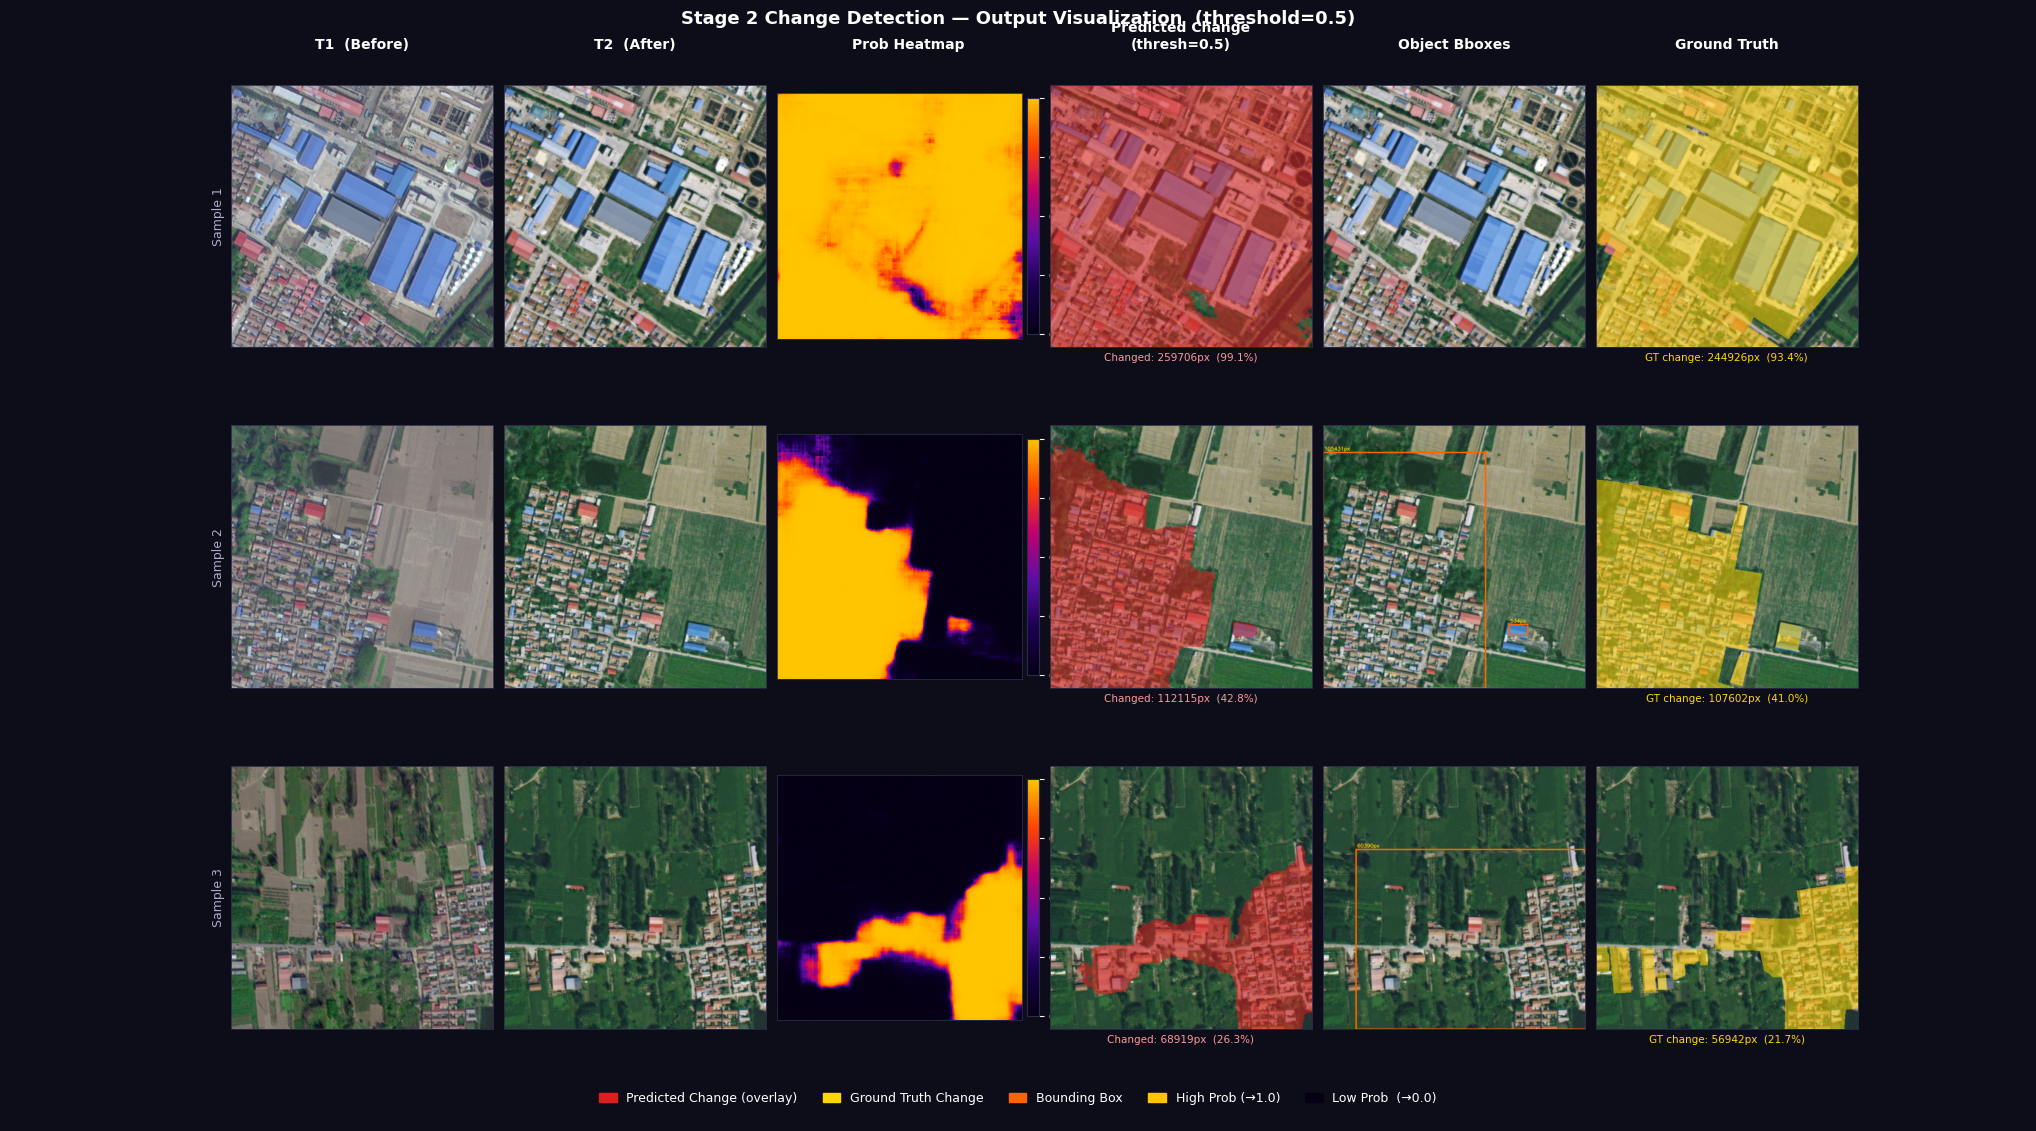


 Sample |   GT px |  Pred px |    GT% |   Pred% |  Match (IoU)
────────────────────────────────────────────────────────────
      1 |  244926 |   259706 |  93.4% |   99.1% |       0.9319
      2 |  107602 |   112115 |  41.0% |   42.8% |       0.8908
      3 |   56942 |    68919 |  21.7% |   26.3% |       0.7037


In [25]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import cv2
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# ── CONFIG ──────────────────────────────────────────────────────────────
N_SAMPLES        = 3       # ← 1 for quick test, up to 5 for presentation
DISPLAY_THRESHOLD = 0.50   # ← raise to 0.60–0.70 if too many FP shown
MIN_BBOX_AREA    = 80      # ← min pixel area for a bbox to appear
BBOX_SEPARATE    = True    # morphological separation before bbox (fixes big boxes)
ALPHA_OVERLAY    = 0.55    # change mask transparency on overlay
SAVE_FIG         = True
# ────────────────────────────────────────────────────────────────────────

MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
STD  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

def denorm(t):
    img = (t.cpu() * STD + MEAN).clamp(0,1)
    return (img.permute(1,2,0).numpy() * 255).astype(np.uint8)

prob_cmap = LinearSegmentedColormap.from_list(
    "prob", ["#050014","#1a0050","#5b0ea6","#c0006e","#ff4500","#ffc500"], N=256)

# ── Collect samples ──────────────────────────────────────────────────────
model_s1.eval(); model_s2.eval()
samples = []

with torch.no_grad():
    for img1_b, img2_b, mask_b in test_loader:
        img1_b = img1_b.to(device)
        img2_b = img2_b.to(device)
        mask_b = mask_b.to(device)
        B = img1_b.shape[0]
        for i in range(B):
            if len(samples) >= N_SAMPLES:
                break
            with torch.amp.autocast('cuda'):
                p1, diff4, diff3_attn, diff2_raw = \
                    model_s1.forward_with_stage2_features(
                        img1_b[i:i+1], img2_b[i:i+1])
                p2 = model_s2(diff3_attn, diff4, diff2_raw, p1)

            prob  = torch.sigmoid(p2)[0,0].cpu().numpy()   # [H,W] 0-1
            pred  = (prob > DISPLAY_THRESHOLD).astype(np.uint8)
            gt    = mask_b[i,0].cpu().numpy().astype(np.uint8)

            # Skip fully-blank samples (no GT change) for cleaner demo
            if gt.sum() < 100 and len(samples) < N_SAMPLES - 1:
                continue

            samples.append({
                "img1": denorm(img1_b[i].cpu()),
                "img2": denorm(img2_b[i].cpu()),
                "prob": prob,
                "pred": pred,
                "gt"  : gt,
            })
        if len(samples) >= N_SAMPLES:
            break

# ── Helper: clean overlay (T2 image + semi-transparent change mask only) ─
def make_clean_overlay(img_rgb, binary_mask, color, alpha=ALPHA_OVERLAY):
    """
    Shows img_rgb normally. Only paints `color` on pixels where mask==1.
    No tinting of background — unchanged areas stay as original T2.
    """
    result = img_rgb.copy().astype(np.float32)
    c = np.array(color, dtype=np.float32)
    px = binary_mask.astype(bool)
    result[px] = result[px] * (1 - alpha) + c * alpha
    return result.clip(0, 255).astype(np.uint8)

# ── Helper: separated bounding boxes ─────────────────────────────────────
def draw_separated_bboxes(img_rgb, pred_bin,
                           min_area=MIN_BBOX_AREA,
                           separate=BBOX_SEPARATE):
    """
    Applies erosion to break touching objects before connected components.
    Draws individual tight boxes per building, not one giant box.
    """
    canvas = img_rgb.copy()

    if separate:
        # Erode to separate touching buildings, then dilate back for bbox
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
        separated = cv2.erode(pred_bin, kernel, iterations=2)
    else:
        separated = pred_bin

    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        separated, connectivity=8)

    for j in range(1, n_labels):
        area = stats[j, cv2.CC_STAT_AREA]
        if area < min_area:
            continue
        x = stats[j, cv2.CC_STAT_LEFT]
        y = stats[j, cv2.CC_STAT_TOP]
        w = stats[j, cv2.CC_STAT_WIDTH]
        h = stats[j, cv2.CC_STAT_HEIGHT]
        # Skip boxes that fill >60% of the image (likely FP flood)
        if w * h > 0.60 * pred_bin.shape[0] * pred_bin.shape[1]:
            continue
        # Tight colored box
        cv2.rectangle(canvas, (x, y), (x+w, y+h),
                      color=(255, 100, 0), thickness=2)
        # Small area label
        cv2.putText(canvas, f"{area}px", (x+2, max(y-4, 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.32, (255,200,0), 1,
                    cv2.LINE_AA)
    return canvas

# ── Plot: 6 columns per sample ───────────────────────────────────────────
#  Col 0: T1
#  Col 1: T2
#  Col 2: Probability heatmap
#  Col 3: T2 + change overlay (red = predicted change only)
#  Col 4: T2 + separated bounding boxes
#  Col 5: T2 + GT overlay (gold = actual change)

COL_TITLES = ["T1  (Before)", "T2  (After)",
               "Prob Heatmap",
               f"Predicted Change\n(thresh={DISPLAY_THRESHOLD})",
               "Object Bboxes",
               "Ground Truth"]

COLS = 6
ROWS = N_SAMPLES
fig = plt.figure(figsize=(COLS * 3.5, ROWS * 3.5 + 0.9),
                 facecolor="#0d0d1a")
gs  = gridspec.GridSpec(ROWS, COLS,
                         figure=fig,
                         hspace=0.06, wspace=0.04,
                         top=0.94, bottom=0.06)

for c, title in enumerate(COL_TITLES):
    ax = fig.add_subplot(gs[0, c])
    ax.set_title(title, color="white", fontsize=10,
                  fontweight="bold", pad=5,
                  multialignment="center")
    ax.axis("off")

for r, s in enumerate(samples):
    pred_overlay = make_clean_overlay(
        s["img2"], s["pred"],
        color=[220, 30, 30])          # red = predicted change

    gt_overlay   = make_clean_overlay(
        s["img2"], s["gt"],
        color=[255, 210, 0])          # gold = ground truth change

    bbox_img     = draw_separated_bboxes(s["img2"], s["pred"])

    # Build contour outline for change mask (shows boundary, not flood fill)
    contours, _ = cv2.findContours(
        s["pred"], cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contour_img  = s["img2"].copy()
    cv2.drawContours(contour_img, contours, -1, (255, 60, 60), 2)

    panels = [
        (s["img1"],    None,      {}),
        (s["img2"],    None,      {}),
        (s["prob"],    prob_cmap, {"vmin": 0, "vmax": 1}),
        (pred_overlay, None,      {}),
        (bbox_img,     None,      {}),
        (gt_overlay,   None,      {}),
    ]

    for c_idx, (data, cmap, kwargs) in enumerate(panels):
        ax = fig.add_subplot(gs[r, c_idx])
        ax.set_facecolor("#0d0d1a")
        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values():
            sp.set_edgecolor("#2a2a4a"); sp.set_linewidth(0.6)

        if cmap:
            im = ax.imshow(data, cmap=cmap, **kwargs)
            if c_idx == 2:   # prob map colorbar
                cb = plt.colorbar(im, ax=ax,
                                   fraction=0.045, pad=0.02,
                                   ticks=[0, 0.25, 0.5, 0.75, 1.0])
                cb.ax.tick_params(colors="white", labelsize=6.5)
                cb.outline.set_edgecolor("#2a2a4a")
                cb.set_label("P(change)", color="white",
                              fontsize=7, labelpad=3)
        else:
            ax.imshow(data)

        # Change pixel count annotation
        if c_idx == 3:
            n_px = int(s["pred"].sum())
            pct  = 100 * n_px / (s["pred"].shape[0] * s["pred"].shape[1])
            ax.set_xlabel(f"Changed: {n_px}px  ({pct:.1f}%)",
                           color="#ff9999", fontsize=7.5)
        if c_idx == 5:
            n_gt = int(s["gt"].sum())
            pct_gt = 100 * n_gt / (s["gt"].shape[0] * s["gt"].shape[1])
            ax.set_xlabel(f"GT change: {n_gt}px  ({pct_gt:.1f}%)",
                           color="#ffd700", fontsize=7.5)

        if c_idx == 0:
            ax.set_ylabel(f"Sample {r+1}",
                           color="#aaaacc", fontsize=9, labelpad=4)

# ── Legend ───────────────────────────────────────────────────────────────
legend_ax = fig.add_axes([0.02, 0.005, 0.96, 0.04])
legend_ax.set_facecolor("#0d0d1a"); legend_ax.axis("off")
patches = [
    mpatches.Patch(color="#dc1e1e", label="Predicted Change (overlay)"),
    mpatches.Patch(color="#ffd700", label="Ground Truth Change"),
    mpatches.Patch(color=(1.0, 0.39, 0.0), label="Bounding Box"),
    mpatches.Patch(color="#ffc500", label="High Prob (→1.0)"),
    mpatches.Patch(color="#050014", label="Low Prob  (→0.0)"),
]
legend_ax.legend(handles=patches, loc="center", ncol=5,
                  frameon=False, labelcolor="white",
                  fontsize=9, handlelength=1.4)

fig.suptitle(
    "Stage 2 Change Detection — Output Visualization  "
    f"(threshold={DISPLAY_THRESHOLD})",
    color="white", fontsize=13, fontweight="bold")

if SAVE_FIG:
    fig.savefig("stage2_visualization.png", dpi=160,
                 bbox_inches="tight", facecolor="#0d0d1a")
    print("Saved → stage2_visualization.png")

plt.show()

# ── Per-sample stats ──────────────────────────────────────────────────────
print(f"\n{'Sample':>7} | {'GT px':>7} | {'Pred px':>8} | "
      f"{'GT%':>6} | {'Pred%':>7} | {'Match (IoU)':>12}")
print("─" * 60)
for i, s in enumerate(samples):
    gt_px   = int(s["gt"].sum())
    pred_px = int(s["pred"].sum())
    inter   = int((s["gt"] & s["pred"]).sum())
    union   = int((s["gt"] | s["pred"]).sum())
    iou     = inter / union if union > 0 else 0.0
    H, W    = s["gt"].shape
    print(f"{i+1:>7} | {gt_px:>7} | {pred_px:>8} | "
          f"{100*gt_px/(H*W):>5.1f}% | {100*pred_px/(H*W):>6.1f}% | "
          f"{iou:>12.4f}")
